# 04 — RQ3 synthesis (consistency of winners)

Computes the pooled pairwise Wilcoxon / Holm / Vargha–Delaney A12 **once** and reuses it for: winners matrix, geomean-normalized table, ranking-stability slopegraph, non-significance clique diagram, A12 forest, and the full pairwise appendix table.

Pairwise is computed on iterations **pooled across passes** (national cells have only ~3/pass < the n≥6 Wilcoxon floor, ~9 pooled).

**Friedman omnibus has no thesis float** (it is reported inline as prose). Its value is computed, printed, and written to `tables/06-friedman-omnibus-values.json` for you to quote — no `.tex` float is fabricated.

In [1]:
import os, json
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
from src.plotting.style import StyleConfig
from src.analysis.tables import build_cost_summary
from src.analysis import thesis_compute as tc
from src.analysis import thesis_tables as tt
from src.plotting import thesis_figures as tf

style = StyleConfig(); style.apply_rcparams()
CACHE = os.environ.get("DOPPA_CACHE", "cache/bench-cache.duckdb")
RUN_ID = "2026-05-26-OY0CN3"
FIG = Path("figures"); TAB = Path("tables")

experiments, samples_df, metadata_df, costs_df, successful = tc.load_all(
    CACHE, "../doppa/benchmarks.yml", RUN_ID)
cost_summary = build_cost_summary(costs_df)
pooled = tc.pooled_pairwise_table(successful)
sysvals = tc.rq3_system_values(successful, cost_summary)
geomean = tc.rq3_geomean(sysvals)
winners = tc.rq3_winners(sysvals)
ranks = tc.rq3_ranks(sysvals)
print("pooled pairwise rows:", len(pooled))

pooled pairwise rows: 327


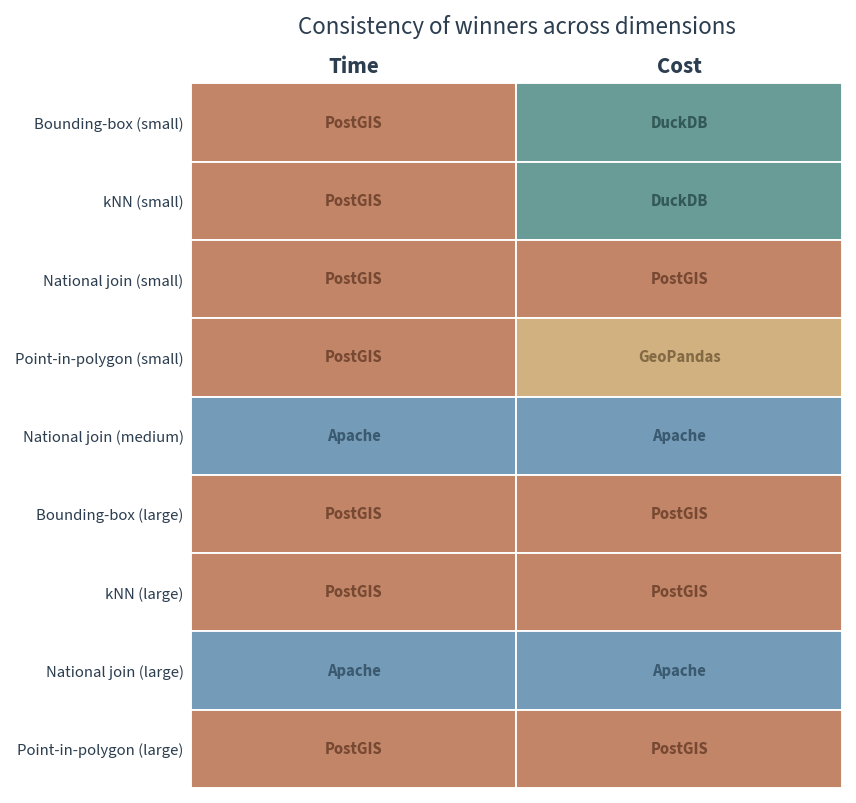

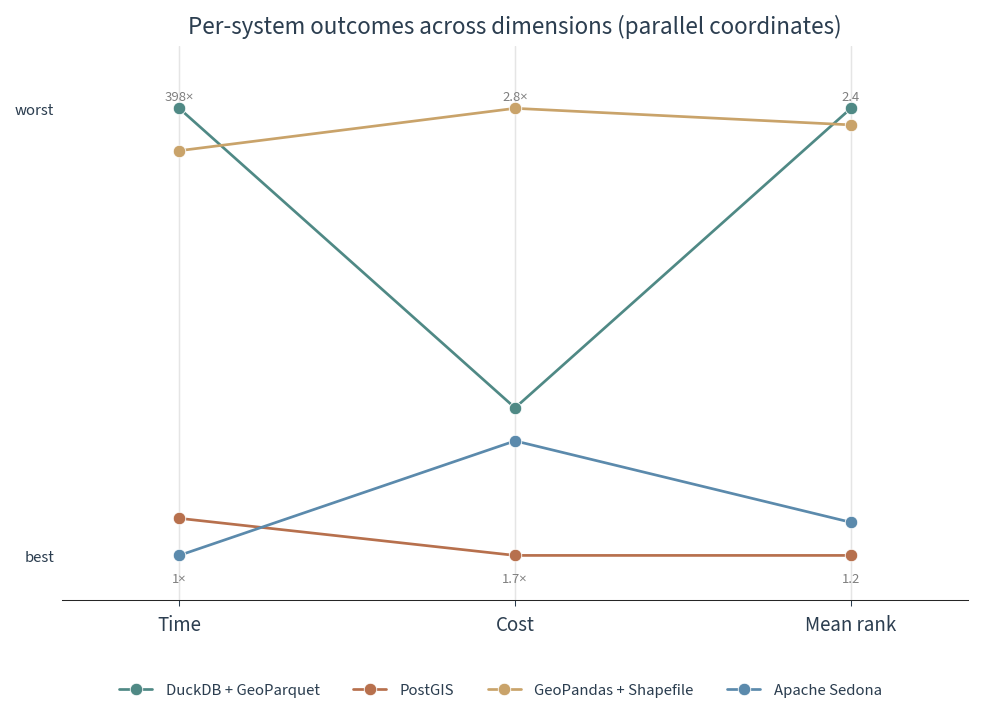

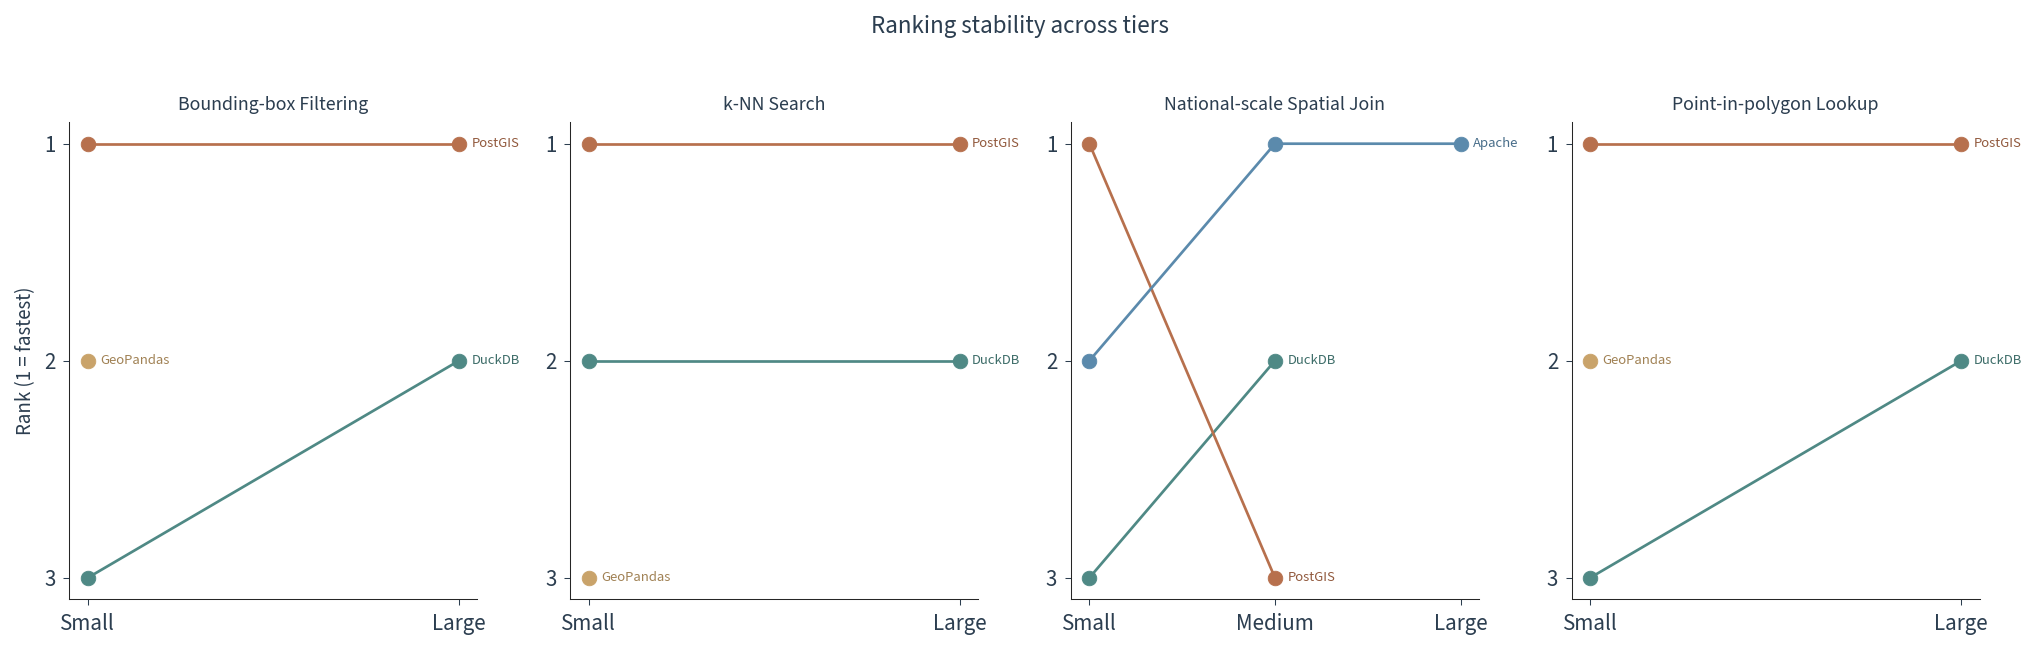

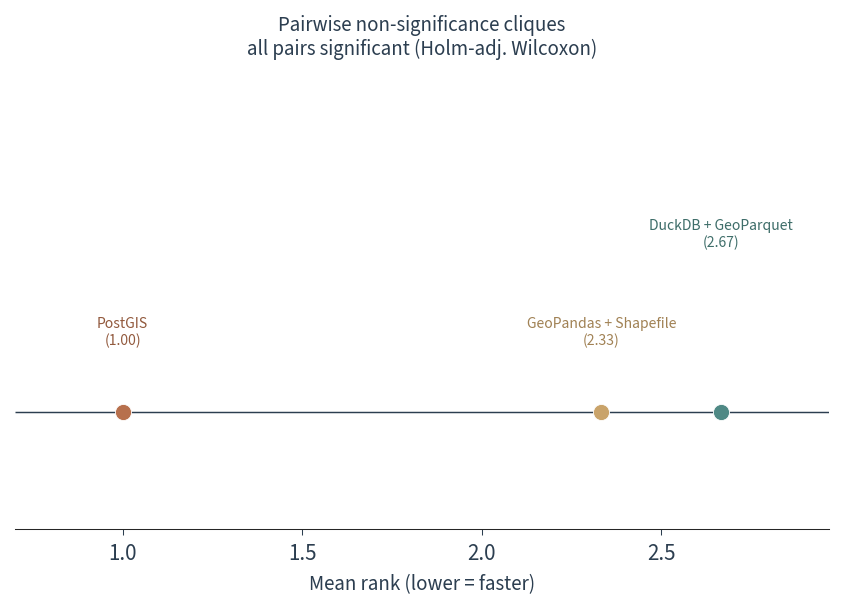

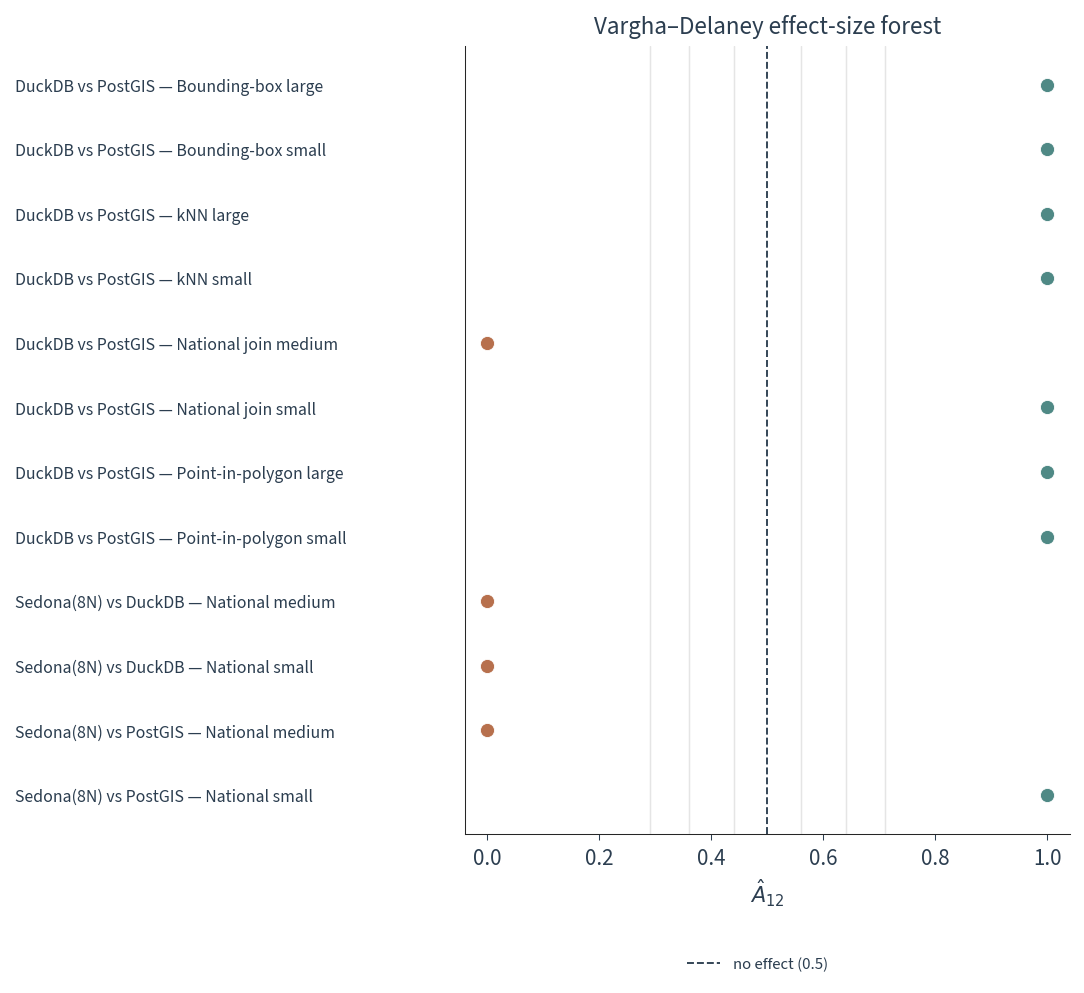

PosixPath('figures/06-vargha-delaney-forest.png')

In [2]:
tf.fig_winners_matrix(winners, style, FIG / "06-winners-matrix.png")
paxes = tc.rq3_parallel_axes(geomean, ranks)
tf.fig_rq3_parallel_coords(paxes, style, FIG / "06-outcome-parallel-coordinates.png")
tf.fig_ranking_stability(ranks, style, FIG / "06-ranking-stability.png")
mean_ranks, nonsig = tc.rq1_cliques(successful, pooled)
tf.fig_cliques(mean_ranks, nonsig, style, FIG / "06-pairwise-significance-cliques.png")
forest = tc.a12_forest(pooled)
tf.fig_a12_forest(forest, style, FIG / "06-vargha-delaney-forest.png")

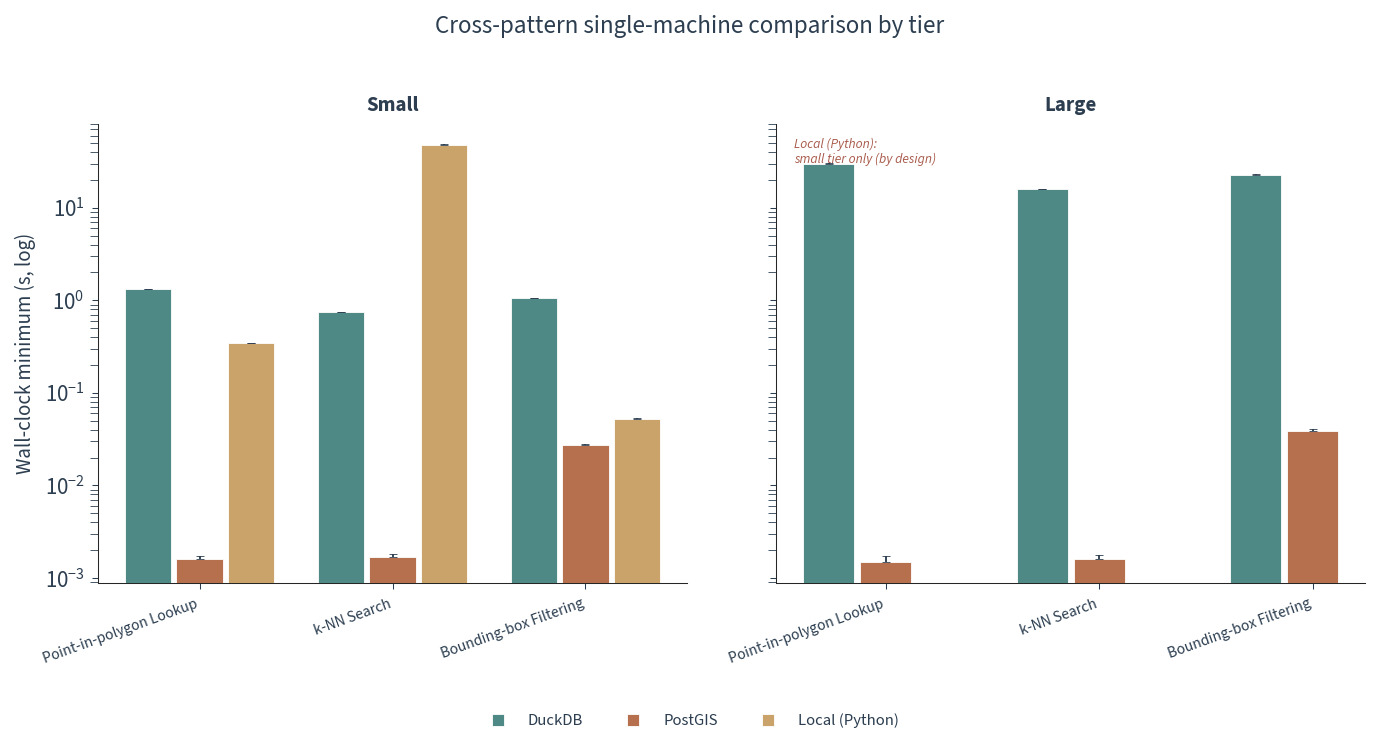

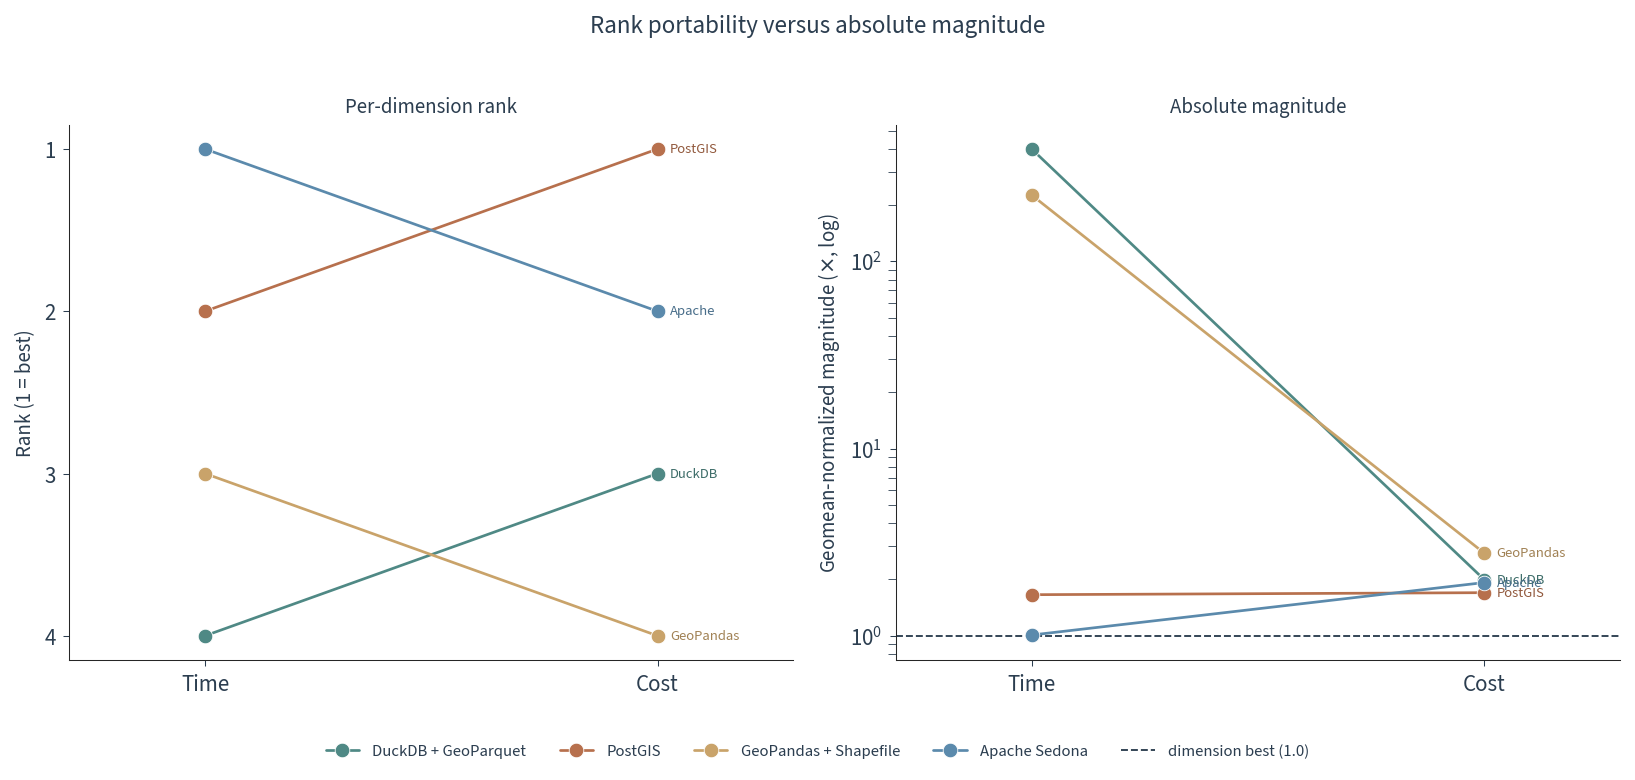

PosixPath('figures/06-rank-portability.png')

In [3]:
# --- New RQ3 cross-pattern + rank-portability figures (thesis_figures.fig_*) ---
RQ1_W = ["point-in-polygon-lookup", "knn-search", "bbox-filtering"]
RQ1_C = ["duckdb", "postgis", "local"]
TIERS = ["small", "large"]
tf.fig_cross_pattern(successful, RQ1_W, RQ1_C, TIERS, style, FIG / "06-single-machine-cross-pattern.png")
tf.fig_rank_portability(geomean, style, FIG / "06-rank-portability.png")

## Tables: geomean, full pairwise; Friedman value (no float)

In [4]:
tt.emit_geomean(geomean, TAB / "06-rq3-geomean.tex")
tt.emit_pairwise(tc.format_pairwise_for_table(pooled), TAB / "08-pairwise-statistics.tex")
rank_matrix, rank_meta = tc.rq3_rank_matrix(successful)
fr = tc.rq3_friedman_omnibus(rank_matrix, rank_meta)
print("Friedman omnibus (RQ3, workload\u00d7tier cell blocks):", fr)
(TAB / "06-friedman-omnibus-values.json").write_text(json.dumps(fr, indent=2))

# Decision-quadrant support data (NOT a figure): per workload×tier×outcome winner,
# runner-up, margin, and Holm-Wilcoxon significance / tie. For the hand-drawn
# Discussion "which engine when" quadrant to be redrawn from, not guessed.
winners_export = tc.rq3_winners_export(sysvals, pooled, successful)
winners_export.to_csv(TAB / "08-decision-quadrant-winners.csv", index=False)
display(geomean); display(winners); display(winners_export)

Friedman omnibus (RQ3, workload×tier cell blocks): {'metric': 'elapsed_time', 'chi2': 4.666666666666664, 'p': 0.09697196786440515, 'df': 2, 'k_configs': 3, 'n_blocks': 3, 'blocking': 'workload×tier cells', 'included_configs': ['duckdb', 'postgis', 'local'], 'included_cells': ['Bounding-box, small', 'kNN, small', 'Point-in-polygon, small'], 'excluded_cells': {'Bounding-box, large': 'incomplete block (ran: duckdb, postgis)', 'kNN, large': 'incomplete block (ran: duckdb, postgis)', 'Point-in-polygon, large': 'incomplete block (ran: duckdb, postgis)'}, 'scope': 'single-machine RQ1 cells only; the national-scale join and Apache Sedona are excluded because Sedona ran the join alone, so no complete ≥3-treatment block spans them with the single-machine engines', 'note': 'Complete-block restriction leaves only 3 cells (Shapefile ran the small tier only), so the omnibus is low-powered and spans query patterns at the small tier rather than across tiers; reported as a limitation rather than overcl

,Time,Cost
duckdb,398.454421,1.995262
postgis,1.657716,1.699407
local,226.103463,2.763804
sedona,1.009435,1.924834


,Time,Cost
Bounding-box (small),postgis,duckdb
kNN (small),postgis,duckdb
National join (small),postgis,postgis
Point-in-polygon (small),postgis,local
National join (medium),sedona,sedona
Bounding-box (large),postgis,postgis
kNN (large),postgis,postgis
National join (large),sedona,sedona
Point-in-polygon (large),postgis,postgis


,workload_type,tier,wt_tier,outcome,winner,winner_value,runner_up,runner_up_value,rel_margin_pct,holm_p,decision
0,bbox-filtering,small,Bounding-box (small),Cost,duckdb,0.184659,local,0.203407,1.015284e+01,NaN,clear
1,bbox-filtering,small,Bounding-box (small),Time,postgis,0.027331,local,0.052097,9.061582e+01,0.000000e+00,significant
2,bbox-filtering,large,Bounding-box (large),Cost,postgis,0.396554,duckdb,1.420954,2.583253e+02,NaN,clear
3,bbox-filtering,large,Bounding-box (large),Time,postgis,0.038937,duckdb,22.826123,5.852330e+04,2.385530e-64,significant
4,knn-search,small,kNN (small),Cost,duckdb,0.173612,postgis,0.397030,1.286872e+02,NaN,clear
5,knn-search,small,kNN (small),Time,postgis,0.001683,duckdb,0.746047,4.423819e+04,0.000000e+00,significant
6,knn-search,large,kNN (large),Cost,postgis,0.395057,duckdb,1.146114,1.901134e+02,NaN,clear
7,knn-search,large,kNN (large),Time,postgis,0.001617,duckdb,15.736374,9.728679e+05,1.160262e-73,significant
8,national-scale-spatial-join,small,National join (small),Cost,postgis,0.053280,duckdb,0.169867,2.188203e+02,NaN,clear
9,national-scale-spatial-join,small,National join (small),Time,postgis,13.365155,sedona,13.747047,2.857371e+00,2.578125e-01,n.s.
